In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics
df = pd.read_csv('/home/rgukt-basar/Downloads/car_data.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [2]:
df.shape

(301, 9)

In [3]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
 df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [5]:
#checking distribution of cat data
print(df.Fuel_Type.value_counts())
print(df.Selling_type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


In [6]:
#encodion text data 
df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)



/tmp/ipykernel_3597/2317124829.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)


In [7]:
df.replace({'Selling_type':{'Dealer':0,'Individual':1}},inplace=True)


/tmp/ipykernel_3597/2453118636.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Selling_type':{'Dealer':0,'Individual':1}},inplace=True)


In [8]:
df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipykernel_3597/3240615976.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


In [9]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


In [10]:
x=df.drop(['Car_Name','Selling_Price'],axis=1)
y=df['Selling_Price']

In [11]:
print(x)

     Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
0    2014           5.59       27000          0             0             0   
1    2013           9.54       43000          1             0             0   
2    2017           9.85        6900          0             0             0   
3    2011           4.15        5200          0             0             0   
4    2014           6.87       42450          1             0             0   
..    ...            ...         ...        ...           ...           ...   
296  2016          11.60       33988          1             0             0   
297  2015           5.90       60000          0             0             0   
298  2009          11.00       87934          0             0             0   
299  2017          12.50        9000          1             0             0   
300  2016           5.90        5464          0             0             0   

     Owner  
0        0  
1        0  
2        0  

In [12]:
print(y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=2)

In [14]:
linear_reg=LinearRegression()

In [15]:
linear_reg.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
training_data_pred=linear_reg.predict(x_train)

In [17]:
#R sqaured error
error_score=metrics.r2_score(y_train,training_data_pred)
print("R squared error :",error_score)

R squared error : 0.8796483009370204


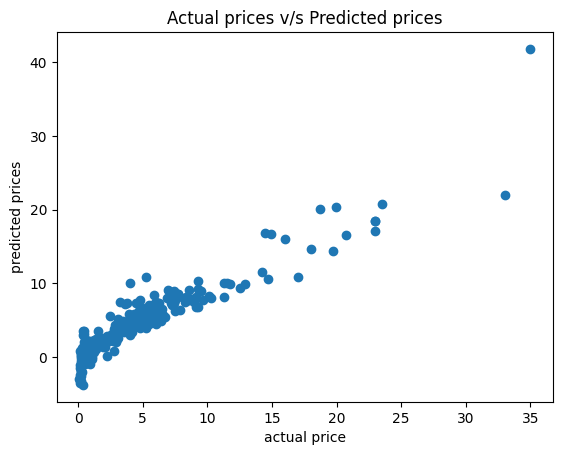

In [18]:
plt.scatter(y_train,training_data_pred)
plt.xlabel("actual price")
plt.ylabel("predicted prices")
plt.title("Actual prices v/s Predicted prices")
plt.show()

In [19]:
test_data_prediction=linear_reg.predict(x_test)


In [20]:
error_score=metrics.r2_score(y_test,test_data_prediction)
print("R squared error :",error_score)

R squared error : 0.8365861023211348


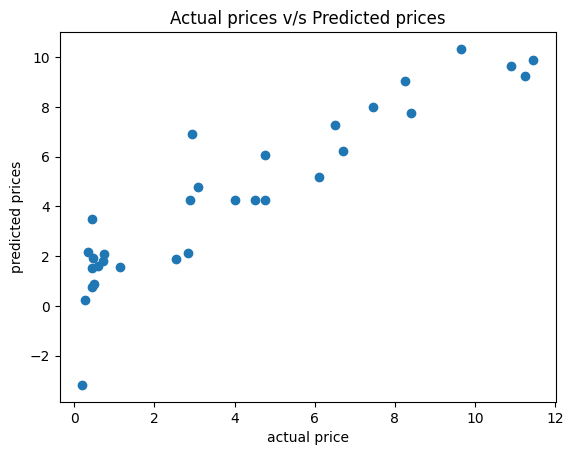

In [21]:
plt.scatter(y_test,test_data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted prices")
plt.title("Actual prices v/s Predicted prices")
plt.show()

In [22]:
#Lasso Regression
lass_reg_model=Lasso()

In [23]:
lass_reg_model.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [24]:
training_data_pred=lass_reg_model.predict(x_train)

In [25]:
error_score=metrics.r2_score(y_train,training_data_pred)
print("R squared error :",error_score)

R squared error : 0.842448071824074


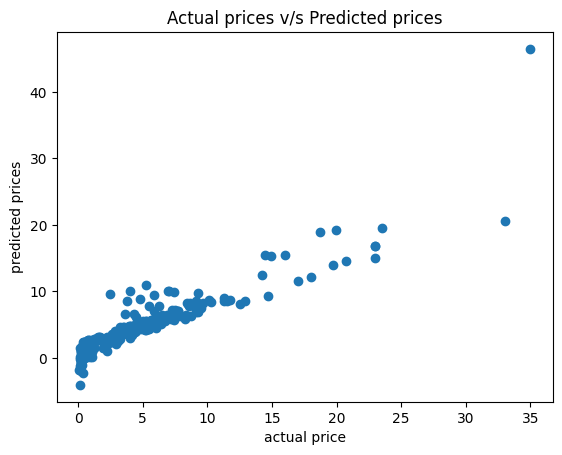

In [26]:
plt.scatter(y_train,training_data_pred)
plt.xlabel("actual price")
plt.ylabel("predicted prices")
plt.title("Actual prices v/s Predicted prices")
plt.show()

In [27]:
test_data_prediction=lass_reg_model.predict(x_test)

In [28]:
error_score=metrics.r2_score(y_test,test_data_prediction)
print("R squared error :",error_score)

R squared error : 0.8709763132343402


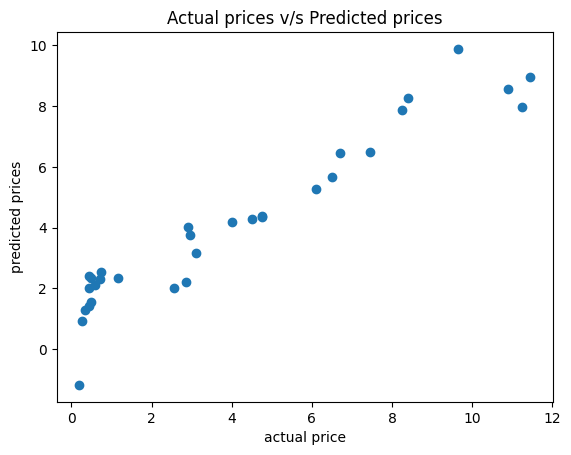

In [29]:
plt.scatter(y_test,test_data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted prices")
plt.title("Actual prices v/s Predicted prices")
plt.show()

In [30]:
import joblib
joblib.dump(df, 'car_price_model.pkl')


['car_price_model.pkl']

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Step 1: Load data
df = pd.read_csv('/home/rgukt-basar/Downloads/car_data.csv')

# Step 2: Feature engineering
df['Car_Age'] = 2025 - df['Year']  # Replace 2025 with current year
df.drop('Year', axis=1, inplace=True)

# Step 3: Define features and target
X = df[['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Car_Age']]
y = df['Selling_Price']

# Step 4: Preprocessing
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
numeric_cols = ['Present_Price', 'Driven_kms', 'Car_Age']

preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

# Step 5: Create pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

# Step 6: Train/test split and model training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
pipeline.fit(X_train, y_train)

# Step 7: Save the pipeline (model + preprocessing)
joblib.dump(pipeline, 'car_price_model.pkl')
print("✅ Model trained and saved as car_price_model.pkl")


✅ Model trained and saved as car_price_model.pkl


In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()          # ✅ Create model object
model.fit(x_train, y_train)         # ✅ Train the model


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
import joblib
joblib.dump(model, 'car_price_model.pkl')


['car_price_model.pkl']